Customer Churn analysis

In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Database Connection Configuration
USER, PASSWORD, HOST, DB = 'bt4301', 'password', 'localhost', 'customer_churn'
engine = create_engine(f'mysql+pymysql://{USER}:{PASSWORD}@{HOST}/{DB}')

Load Data

In [6]:
query = """
SELECT
    f.customer_id,
    f.churn,
    f.monthlycharges,
    f.totalcharges,
    f.avg_charge_per_month,
    c.age,
    c.gender,
    c.annual_income,
    c.education,
    c.marital_status,
    c.dependents,
    c.senior_citizen,
    a.tenure,
    a.contract,
    a.payment_method,
    a.paperless_billing,
    s.num_services,
    s.has_phone_service,
    s.has_internet_service,
    s.has_online_security,
    s.has_online_backup,
    s.has_device_protection,
    s.has_tech_support,
    s.has_streaming_tv,
    s.has_streaming_movies,
    b.customer_satisfaction,
    b.num_complaints,
    b.num_service_calls,
    b.late_payments,
    b.avg_monthly_gb,
    b.days_since_last_interaction,
    b.credit_score,
    b.high_risk_flag
FROM fact_customer_churn f
LEFT JOIN dim_customer  c ON f.customer_id = c.customer_id
LEFT JOIN dim_account   a ON f.customer_id = a.customer_id
LEFT JOIN dim_service   s ON f.customer_id = s.customer_id
LEFT JOIN dim_behavior  b ON f.customer_id = b.customer_id
"""

df = pd.read_sql(query, engine)
print(f"Columns available: {df.columns}")

df.head()

Columns available: Index(['customer_id', 'churn', 'monthlycharges', 'totalcharges',
       'avg_charge_per_month', 'age', 'gender', 'annual_income', 'education',
       'marital_status', 'dependents', 'senior_citizen', 'tenure', 'contract',
       'payment_method', 'paperless_billing', 'num_services',
       'has_phone_service', 'has_internet_service', 'has_online_security',
       'has_online_backup', 'has_device_protection', 'has_tech_support',
       'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction',
       'num_complaints', 'num_service_calls', 'late_payments',
       'avg_monthly_gb', 'days_since_last_interaction', 'credit_score',
       'high_risk_flag'],
      dtype='object')


,customer_id,churn,monthlycharges,totalcharges,avg_charge_per_month,age,gender,annual_income,education,marital_status,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,high_risk_flag
0,CUST0000000047,0,115.93,5894.70,109.161111,47,Female,30347.14,college,single,...,1,0,8.0,0.0,0,0,36.13,5,804.0,0
1,CUST0000000091,0,128.81,6431.69,133.993542,45,Male,48894.76,master,married,...,0,0,7.0,0.0,0,0,40.42,92,550.0,1
2,CUST0000000140,0,65.82,1391.53,66.263333,56,Female,71159.08,bachelor,married,...,0,1,6.0,1.0,2,0,0.00,19,758.0,0
3,CUST0000000202,0,56.14,3541.49,59.024833,32,Male,20000.00,high_school,divorced,...,1,0,5.0,0.0,1,1,13.80,41,676.0,0
4,CUST0000000214,0,59.11,64.09,64.090000,41,Female,34528.27,bachelor,married,...,1,0,8.0,0.0,2,1,15.74,8,634.0,0


## Churn & unchurned by age (grouped bar)


In [10]:
# Create age groups
import seaborn as sns
import matplotlib.pyplot as plt

# create age_group column
df['age_group'] = pd.cut(df['age'], 
                         bins=[18, 30, 40, 50, 60, 70, 100], 
                         labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+'])

sns.set_theme(style="whitegrid")

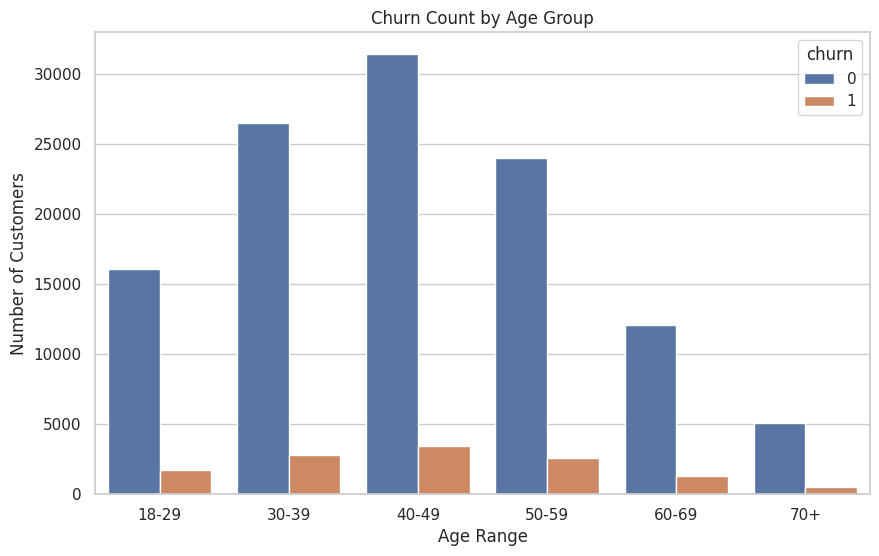

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='age_group', hue='churn')
plt.title('Churn Count by Age Group')
plt.xlabel('Age Range')
plt.ylabel('Number of Customers')
plt.show()

## Contract type vs churn


In [15]:
# Different contract types
df['contract'].unique()

array(['one_year', 'two_year', 'month_to_month'], dtype=object)

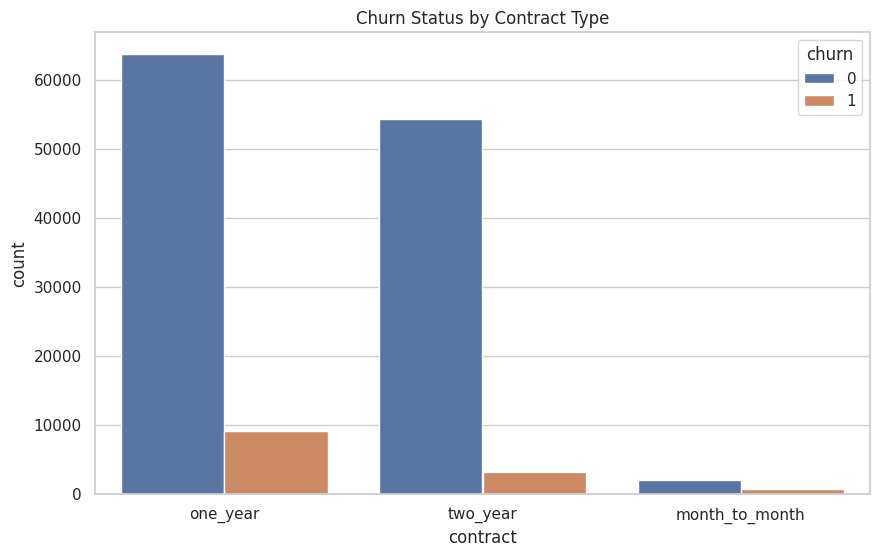

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='contract', hue='churn')
plt.title('Churn Status by Contract Type')
plt.show()

## Monthly charge vs churn


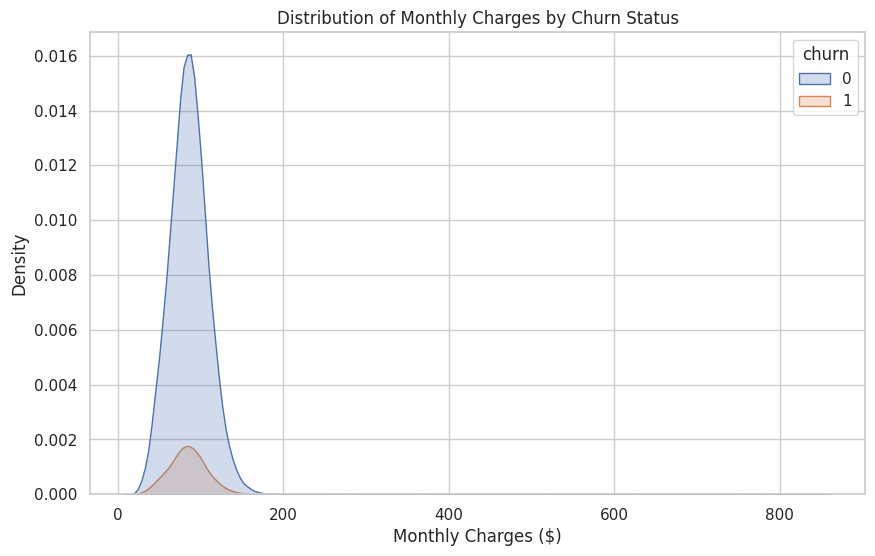

In [16]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='monthlycharges', hue='churn', fill=True)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.show()

## Tenure distribution by churn

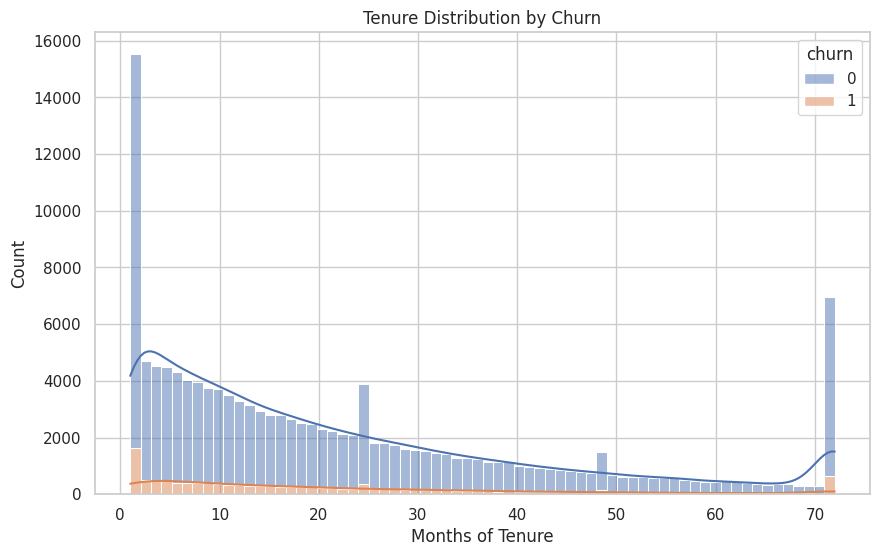

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='churn', multiple="stack", kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Months of Tenure')
plt.show()